In [10]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


In [11]:
import pandas as pd

data = pd.read_csv("titanic.csv")
print(data.head())
print(data.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

Survival Count:
 Survived
0    549
1    342
Name: count, dtype: int64


/tmp/ipykernel_4096/1919542108.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].mean(), inplace=True)
/tmp/ipykernel_4096/1919542108.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

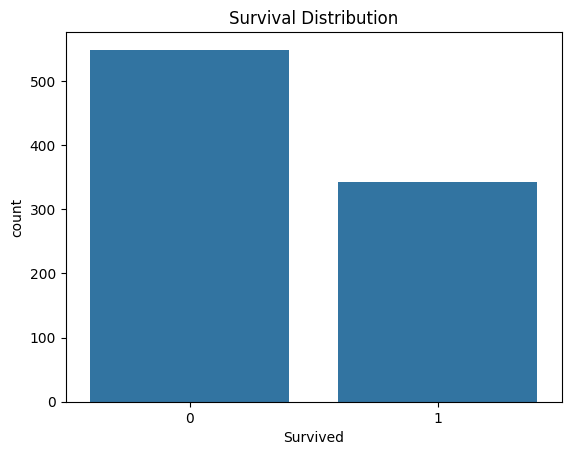


MODEL COMPARISON TABLE:

                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.810056   0.785714  0.743243  0.763889  0.881596
1                  KNN  0.715084   0.688525  0.567568  0.622222  0.772201
2          Naive Bayes  0.776536   0.712500  0.770270  0.740260  0.851351
3        Decision Tree  0.782123   0.727273  0.756757  0.741722  0.782304
4        Random Forest  0.815642   0.797101  0.743243  0.769231  0.879472
5                  SVM  0.659218   0.760000  0.256757  0.383838  0.806950

✅ Model Saved as best_model.pkl

Sample Predictions:
[0 0 0 1 0]


In [12]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ================================
# LOAD DATA
# ================================
data = pd.read_csv("titanic.csv")

# ================================
# BASIC CLEANING
# ================================
data = data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

data["Age"].fillna(data["Age"].mean(), inplace=True)
data["Embarked"].fillna("S", inplace=True)

# ================================
# ENCODING
# ================================
le = LabelEncoder()
data["Sex"] = le.fit_transform(data["Sex"])
data["Embarked"] = le.fit_transform(data["Embarked"])

# ================================
# EDA (SIMPLE)
# ================================
print("Survival Count:\n", data["Survived"].value_counts())

sns.countplot(x="Survived", data=data)
plt.title("Survival Distribution")
plt.show()

# ================================
# SPLIT DATA
# ================================
X = data.drop("Survived", axis=1)
y = data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# MODELS
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

# ================================
# EVALUATION
# ================================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    try:
        y_prob = model.predict_proba(X_test)[:,1]
    except:
        y_prob = y_pred

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(results, columns=[
    "Model","Accuracy","Precision","Recall","F1","AUC"
])

print("\nMODEL COMPARISON TABLE:\n")
print(results_df)

# ================================
# BEST MODEL (Random Forest)
# ================================
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

# ================================
# SAVE MODEL
# ================================
pickle.dump(best_model, open("best_model.pkl", "wb"))

print("\n✅ Model Saved as best_model.pkl")

# ================================
# TEST ON NEW SAMPLES
# ================================
print("\nSample Predictions:")
print(best_model.predict(X_test[:5]))

In [ ]:
from google.colab import files
import pandas as pd
import pickle

# ================================
# SAVE FILES (ensure they exist)
# ================================

# Save model (if not already saved)
pickle.dump(best_model, open("best_model.pkl", "wb"))

# Save results table (if not already saved)
results_df.to_csv("results.csv", index=False)

# ================================
# DOWNLOAD FILES
# ================================
files.download("best_model.pkl")
files.download("results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>